In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from retail_data import generate_retail_dataset

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42

In [2]:
# 1. Load Retail Dataset

df = generate_retail_dataset(n_samples=2000, random_state=RANDOM_STATE)
print(f'Shape: {df.shape}')
df.head()

Shape: (2000, 11)


,CustomerID,Age,Annual_Income,Spending_Score,Region,Product_Category,Purchase_Channel,Num_Purchases,Avg_Transaction_Value,Total_Sales,Customer_Segment
0,1,22,107813,32,East,Furniture,In-Store,13,489.18,6663.34,Premium
1,2,58,26206,84,West,Clothing,Online,19,45.83,996.14,Regular
2,3,52,59752,4,East,Sports,In-Store,16,83.28,1471.70,Budget
3,4,40,65826,45,East,Electronics,Online,20,417.10,9209.14,Regular
4,5,40,99787,80,South,Groceries,Online,18,81.11,1467.51,VIP


Target variable: Total_Sales
count     2000.000000
mean      4143.513110
std       2560.604662
min         90.830000
25%       2063.230000
50%       3861.625000
75%       5940.845000
max      13288.110000
Name: Total_Sales, dtype: float64


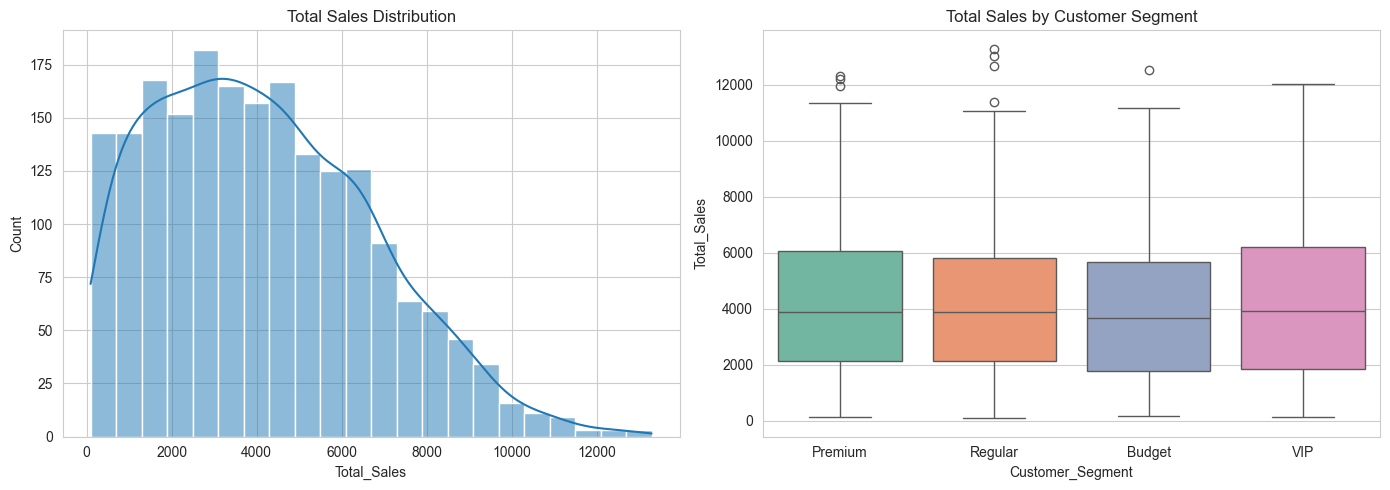

In [8]:

# 2. Exploratory Data Analysis

print('Target variable: Total_Sales')
print(df['Total_Sales'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Total_Sales'], kde=True, ax=axes[0])
axes[0].set_title('Total Sales Distribution')
sns.boxplot(data=df, x='Customer_Segment', y='Total_Sales', ax=axes[1], palette='Set2')
axes[1].set_title('Total Sales by Customer Segment')
plt.tight_layout()
plt.show()

Correlation with Total_Sales:
Avg_Transaction_Value    0.876155
Num_Purchases            0.406550
Spending_Score           0.025307
Annual_Income           -0.003439
Age                     -0.010848
Name: Total_Sales, dtype: float64


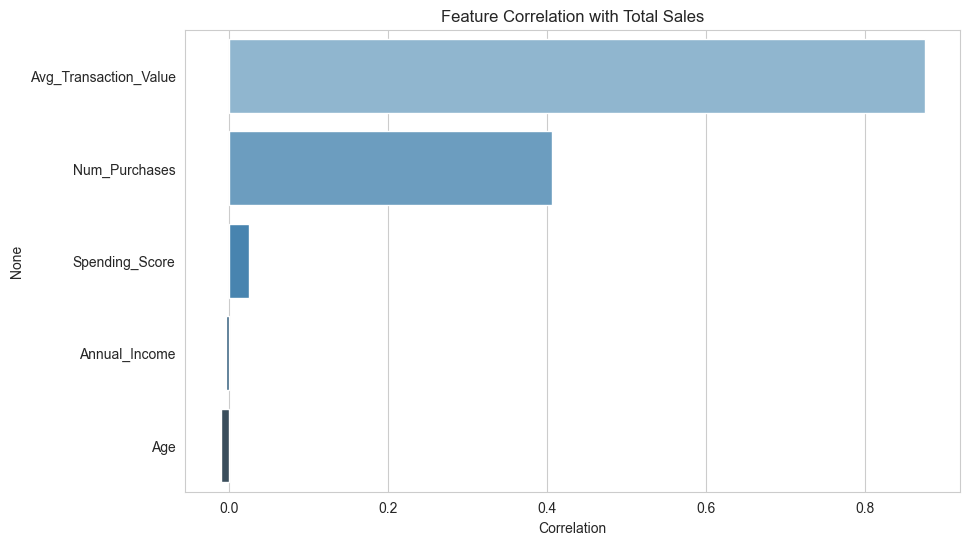

In [9]:
num_features = ['Age', 'Annual_Income', 'Spending_Score', 'Num_Purchases', 'Avg_Transaction_Value']
corr_with_target = df[num_features + ['Total_Sales']].corr()['Total_Sales'].drop('Total_Sales').sort_values(ascending=False)
print('Correlation with Total_Sales:')
print(corr_with_target)

sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette='Blues_d')
plt.title('Feature Correlation with Total Sales')
plt.xlabel('Correlation')
plt.show()

In [10]:
# 3. Feature Engineering & Train/Test Split

cat_features = ['Region', 'Product_Category', 'Purchase_Channel']
target = 'Total_Sales'

X = df[num_features + cat_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 1600, Test: 400


In [ ]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor())
])

In [12]:
# 4. Hyperparameter Tuning (K, Weights, Distance Metric)

param_grid = {
    'regressor__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'regressor__weights': ['uniform', 'distance'],
    'regressor__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    knn_pipeline, param_grid, cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'Best params: {grid_search.best_params_}')
print(f'Best CV MAE: {-grid_search.best_score_:.2f}')

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Best params: {'regressor__metric': 'euclidean', 'regressor__n_neighbors': 15, 'regressor__weights': 'distance'}
Best CV MAE: 669.09


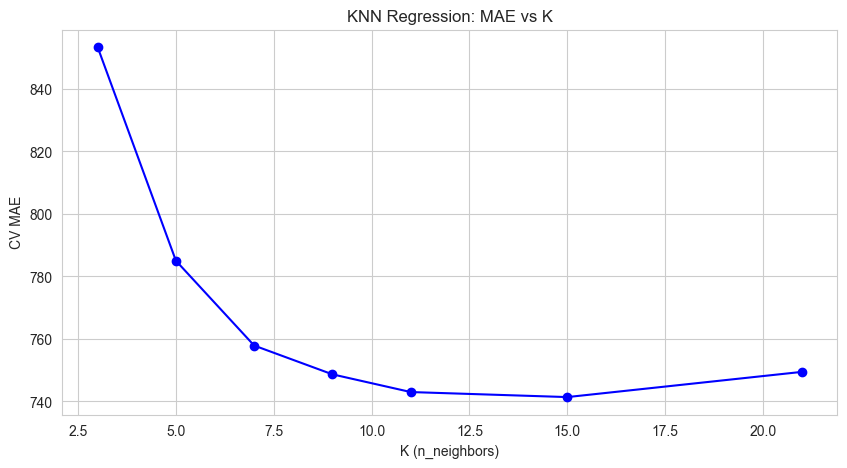

In [16]:
results = pd.DataFrame(grid_search.cv_results_)
k_results = results.groupby('param_regressor__n_neighbors')['mean_test_score'].mean().reset_index()
k_results['mae'] = -k_results['mean_test_score']

plt.figure(figsize=(10, 5))
plt.plot(k_results['param_regressor__n_neighbors'], k_results['mae'], 'bo-')
plt.xlabel('K (n_neighbors)')
plt.ylabel('CV MAE')
plt.title('KNN Regression: MAE vs K')
plt.show()

In [17]:
# 5. Evaluate Best Model on Test Set

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('=== Test Set Performance ===')
print(f'MAE:  ${mae:,.2f}')
print(f'RMSE: ${rmse:,.2f}')
print(f'R²:   {r2:.4f}')

=== Test Set Performance ===
MAE:  $633.74
RMSE: $844.22
R²:   0.8826


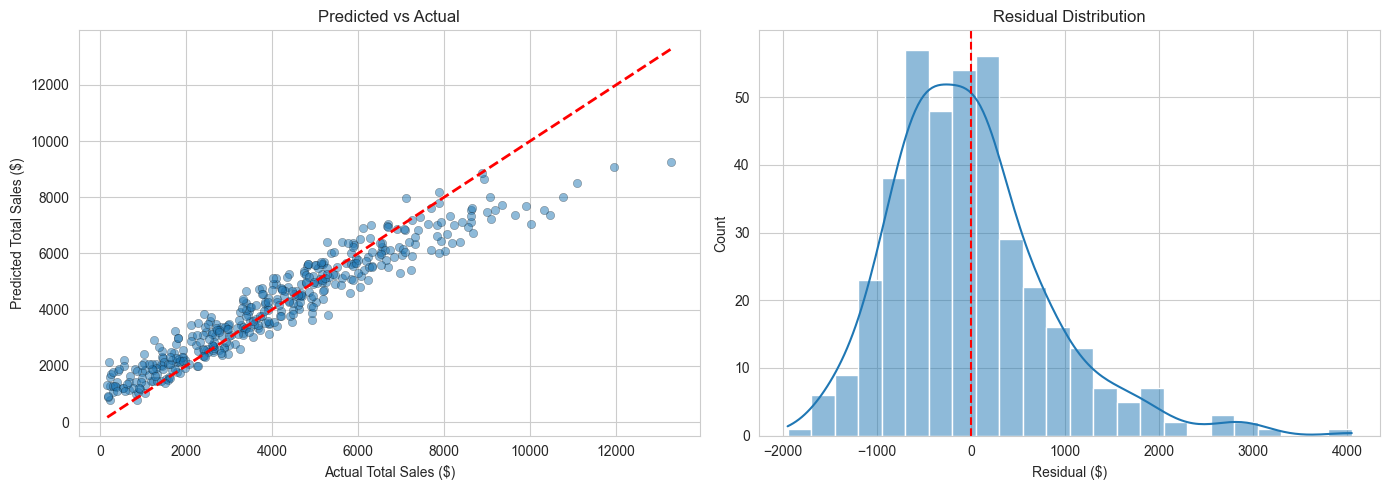

In [18]:
# 6. Visualization: Predicted vs Actual

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidth=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Total Sales ($)')
axes[0].set_ylabel('Predicted Total Sales ($)')
axes[0].set_title('Predicted vs Actual')

residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].axvline(0, color='r', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual ($)')
plt.tight_layout()
plt.show()
     

In [19]:
sample_results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Error': y_test.values - y_pred,
    'Abs_Error_Pct': (np.abs(y_test.values - y_pred) / y_test.values * 100).round(1)
}).head(15)
sample_results

,Actual,Predicted,Error,Abs_Error_Pct
0,3829.68,4214.582103,-384.902103,10.1
1,3915.13,4399.675977,-484.545977,12.4
2,2886.95,2660.048696,226.901304,7.9
3,5374.49,6033.258838,-658.768838,12.3
4,6979.41,5310.563552,1668.846448,23.9
5,5459.96,4908.888095,551.071905,10.1
6,538.23,1202.210930,-663.980930,123.4
7,197.27,2144.465092,-1947.195092,987.1
8,701.62,1630.559458,-928.939458,132.4
9,2966.53,3450.365462,-483.835462,16.3


In [20]:
# 7. Cross-Validation Stability

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'CV R² scores: {cv_scores.round(4)}')
print(f'Mean CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

CV R² scores: [0.8911 0.8909 0.8748 0.8948 0.8792]
Mean CV R²: 0.8862 (+/- 0.0077)


In [21]:
# 8. Make Predictions on New Customers

new_customers = pd.DataFrame({
    'Age': [28, 55, 42],
    'Annual_Income': [45000, 95000, 70000],
    'Spending_Score': [75, 30, 60],
    'Num_Purchases': [20, 8, 15],
    'Avg_Transaction_Value': [45.0, 120.0, 85.0],
    'Region': ['North', 'West', 'East'],
    'Product_Category': ['Electronics', 'Furniture', 'Clothing'],
    'Purchase_Channel': ['Online', 'In-Store', 'Mobile']
})

new_predictions = best_model.predict(new_customers)
new_customers['Predicted_Total_Sales'] = new_predictions.round(2)
new_customers

,Age,Annual_Income,Spending_Score,Num_Purchases,Avg_Transaction_Value,Region,Product_Category,Purchase_Channel,Predicted_Total_Sales
0,28,45000,75,20,45.0,North,Electronics,Online,2140.17
1,55,95000,30,8,120.0,West,Furniture,In-Store,1644.27
2,42,70000,60,15,85.0,East,Clothing,Mobile,1771.32
